In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as st
from pkg import detrend_group, plot_map 

In [2]:
def safe_regress(data, formula=None, yvar=None, xvars=None, ci=None):
    if formula:
        yvar = formula.split("~")[0].strip()
        xvars = formula.split("~")[1].strip().split("+")
        xvars = [x.strip() for x in xvars]


    if formula is None and yvar is None or xvars is None:
        raise ValueError("Provide either formula or yvar + xvars")

    n_obs = len(data.dropna(subset=[yvar] + xvars))
    n_preds = len(xvars) + 1  # +1 for intercept

    if n_obs <= n_preds:
        return pd.DataFrame([{"r2": None, "adj_r2": None}])

    try:
        if formula:
            model = smf.ols(formula=formula, data=data).fit()
        else:
            formula = f"{yvar} ~ {' + '.join(xvars)}"
            model = smf.ols(formula=formula, data=data).fit()

        out = {"r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
            "ftest_pval": model.f_pvalue}
        
        out.update({f"coef_{k}": v for k, v in model.params.items()})
        out.update({f"pval_{k}": v for k, v in model.pvalues.items()})
        
        if ci is not None:
            ci = model.conf_int()
            for k in model.params.index:
                out[f"cilow_{k}"] = ci.loc[k, 0]
                out[f"cihigh_{k}"] = ci.loc[k, 1]

        return pd.DataFrame([out])

    except Exception as e:
        return pd.DataFrame([{"r2": None, "adj_r2": None, "error": str(e)}])

def pval_is_sig(data, column, threshold = 0.05):
    data[f'{column}_pass'] = np.where(data[column] <0.05, True, False )
    return data

def make_pretty_tab_multi(df, cols):
    out = {}
    for col in cols:
        vals = {'low': df.loc[df['quantile']==0.25, col].item(),
            'med': df.loc[df['quantile']==0.5,  col].item(),
            'high': df.loc[df['quantile']==0.75, col].item()}
        out[col] = f"{vals['med']} ({vals['low']}, {vals['high']})"
    return pd.Series(out)


In [3]:
yields = pd.read_csv("./data/yields.csv")
yields= yields.loc[:, ~yields.columns.str.contains("_lag|_lead|fao_idx|gridcells", regex=True)]

sm_tmax = pd.read_csv("./data/sm_tmax.csv")
yields_clim = yields.merge(sm_tmax, how="left", on = ["year", "cropname", "country"])

yields_clim = detrend_group(yields_clim, "sm_og", "sm_dt")
yields_clim = detrend_group(yields_clim, "tmax_og", "tmax_dt")

yields_clim = yields_clim[yields_clim.notna()]

counts = yields_clim[["country", "cropname"]].value_counts()
counts_idx = counts[counts>10].index
yields_clim10 = yields_clim.set_index(['country', 'cropname'])
yields_clim10 =  yields_clim10.loc[counts_idx].reset_index()

In [4]:
res_surv = yields_clim10.groupby(['cropname', 'country']).apply(
    lambda group: safe_regress(group, formula= "yield_log_dt ~ sm_dt + tmax_dt")
    ).reset_index(level=[0,1])
res_surv = res_surv.iloc[:, ~res_surv.columns.str.contains("Intercept", regex=True)]
res_surv['model']="Survey"

res_sat = yields_clim10.groupby(['cropname', 'country']).apply(
    lambda group: safe_regress(group, formula= "csif_log_dt ~ sm_dt + tmax_dt")
    ).reset_index(level=[0,1])
res_sat = res_sat.iloc[:, ~res_sat.columns.str.contains("Intercept", regex=True)]
res_sat['model'] = "Satellite"

res_comb= pd.concat([res_sat, res_surv]).reset_index(drop=True)

[pval_is_sig(res_comb, col) for col in ['pval_sm_dt', 'pval_tmax_dt', 'ftest_pval']]
res_comb= res_comb.dropna(how="any")


In [36]:
nice_tab1_allcrops = res_comb.groupby('model')[['r2', 'adj_r2', 'coef_sm_dt', 'coef_tmax_dt']
                                               ].quantile([0.25, 0.5, 0.75]).round(2).reset_index(
                                               ).rename({'level_1': 'quantile'}, axis=1).groupby('model').apply(lambda x: make_pretty_tab_multi(x, cols))
nice_tab2_allcrops = res_comb.groupby('model')[['pval_sm_dt_pass', 'pval_tmax_dt_pass', 'ftest_pval_pass']].agg(lambda x: str(int(round((sum(x)/ len(x)*100),0)))+"%")


nice_tab_allcrops = pd.merge(nice_tab1_allcrops, nice_tab2_allcrops, right_on = "model", left_on="model")
nice_tab_allcrops['cropname'] = "All crops"
nice_tab_allcrops = nice_tab_allcrops.reset_index().set_index(['cropname', 'model'])


In [37]:
wanted = res_comb[res_comb['cropname'].isin(["Maize", "Sorghum", "Wheat", "Potatoes", "Cassava"]) ]
cols = ["adj_r2", "r2", "coef_sm_dt", "coef_tmax_dt"]

nice_tab1 = wanted.groupby(['cropname', 'model'])[['r2', 'adj_r2', 'coef_sm_dt', 'coef_tmax_dt']
                                                  ].quantile([0.25, 0.5, 0.75]).round(2).reset_index(
                                                  ).rename({'level_2': 'quantile'}, axis=1
                                                  ).groupby(['cropname', 'model']).apply(lambda x: make_pretty_tab_multi(x, cols))

nice_tab2= wanted.groupby(['cropname', 'model'])[['pval_sm_dt_pass', 'pval_tmax_dt_pass', 'ftest_pval_pass']].agg(lambda x: str(int(round((sum(x)/ len(x)*100),0)))+ "%")
nice_table =  pd.merge(nice_tab1, nice_tab2, left_on=(['cropname', "model"]), right_on=(['cropname', 'model']))
nice_table = pd.concat([nice_tab_allcrops, nice_table])

In [ ]:
order = ["All crops", "Maize", "Sorghum", "Wheat", "Cassava", "Potatoes"]
nice_table = nice_table.iloc[: , [1,0, 6, 2,4]].loc[order,:]
nice_table.columns=['R2', "Adj R2", "F-test pass", "SM coefficient", "SM p.v. pass"]


R2               Adj R2 F-test pass  \
cropname  model                                                           
All crops Satellite  0.32 (0.16, 0.52)    0.25 (0.08, 0.46)         60%   
          Survey     0.12 (0.05, 0.23)   0.03 (-0.04, 0.15)         20%   
Maize     Satellite  0.38 (0.21, 0.55)    0.32 (0.11, 0.51)         68%   
          Survey     0.16 (0.05, 0.28)   0.07 (-0.05, 0.21)         27%   
Sorghum   Satellite    0.36 (0.2, 0.6)     0.3 (0.13, 0.56)         68%   
          Survey     0.13 (0.06, 0.23)   0.05 (-0.03, 0.14)         19%   
Wheat     Satellite   0.3 (0.16, 0.53)    0.23 (0.08, 0.49)         55%   
          Survey     0.14 (0.07, 0.27)   0.05 (-0.02, 0.19)         27%   
Cassava   Satellite  0.21 (0.09, 0.36)   0.13 (-0.02, 0.29)         39%   
          Survey     0.11 (0.06, 0.21)   0.01 (-0.04, 0.13)         16%   
Potatoes  Satellite   0.26 (0.1, 0.49)    0.18 (0.01, 0.44)         50%   
          Survey     0.09 (0.03, 0.18)  -0.01 (-0.07, 0.09)         10%   

                         SM coefficient SM p.v. pass  
cropname  model                                       
All crops Satellite   2.66 (0.89, 5.51)          49%  
          Survey     0.81 (-1.24, 4.59)          15%  
Maize     Satellite   2.54 (1.36, 5.27)          52%  
          Survey     1.65 (-0.83, 7.11)          19%  
Sorghum   Satellite   2.96 (1.65, 6.42)          61%  
          Survey     1.66 (-1.57, 5.65)          17%  
Wheat     Satellite   3.26 (1.25, 7.01)          52%  
          Survey       0.92 (-1.7, 6.0)          21%  
Cassava   Satellite   1.04 (0.35, 2.68)          34%  
          Survey     0.24 (-0.51, 2.11)          11%  
Potatoes  Satellite    3.13 (1.25, 6.0)          45%  
          Survey     0.63 (-0.86, 2.93)          11%

In [ ]:
table = nice_table.copy()
cols_to_clean = ["R2", "Adj R2"]
table[cols_to_clean] = table[cols_to_clean].replace(r"\s*\([^)]*\)", "", regex=True)

print(table.to_latex())

\begin{tabular}{lllllll}
\toprule
         &        &    R2 & Adj R2 & F-test pass &      SM coefficient & SM p.v. pass \\
cropname & model &       &        &             &                     &              \\
\midrule
All crops & Satellite &  0.32 &   0.25 &         60\% &   2.66 (0.89, 5.51) &          49\% \\
         & Survey &  0.12 &   0.03 &         20\% &  0.81 (-1.24, 4.59) &          15\% \\
Maize & Satellite &  0.38 &   0.32 &         68\% &   2.54 (1.36, 5.27) &          52\% \\
         & Survey &  0.16 &   0.07 &         27\% &  1.65 (-0.83, 7.11) &          19\% \\
Sorghum & Satellite &  0.36 &    0.3 &         68\% &   2.96 (1.65, 6.42) &          61\% \\
         & Survey &  0.13 &   0.05 &         19\% &  1.66 (-1.57, 5.65) &          17\% \\
Wheat & Satellite &   0.3 &   0.23 &         55\% &   3.26 (1.25, 7.01) &          52\% \\
         & Survey &  0.14 &   0.05 &         27\% &    0.92 (-1.7, 6.0) &          21\% \\
Cassava & Satellite &  0.21 &   0.13 &        

/var/folders/k4/2gcvspsj7d7c9hbxlvzv_zrh0000gn/T/ipykernel_65975/3555677964.py:6: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(table.to_latex())


In [ ]:
full_table = nice_table.replace(r"(\d+\.\d+)\s\(([^)]+)\)", r"\\makecell{\1 \\\\ (\2)}", regex=True)
full_table = full_table.replace("%", r"\\%", regex=True)

print(full_table.to_latex(escape=False))

\begin{tabular}{lllllll}
\toprule
         &        &                               R2 &                             Adj R2 & F-test pass % &                    SM coefficient & SM p-val pass \\
cropname & model &                                  &                                    &               &                                   &               \\
\midrule
All crops & Satellite &  \makecell{0.32 \\ (0.16, 0.52)} &    \makecell{0.25 \\ (0.08, 0.46)} &          60\% &   \makecell{2.66 \\ (0.89, 5.51)} &          49\% \\
         & Survey &  \makecell{0.12 \\ (0.05, 0.23)} &   \makecell{0.03 \\ (-0.04, 0.15)} &          20\% &  \makecell{0.81 \\ (-1.24, 4.59)} &          15\% \\
Maize & Satellite &  \makecell{0.38 \\ (0.21, 0.55)} &    \makecell{0.32 \\ (0.11, 0.51)} &          68\% &   \makecell{2.54 \\ (1.36, 5.27)} &          52\% \\
         & Survey &  \makecell{0.16 \\ (0.05, 0.28)} &   \makecell{0.07 \\ (-0.05, 0.21)} &          27\% &  \makecell{1.65 \\ (-0.83, 7.11)} &      

/var/folders/k4/2gcvspsj7d7c9hbxlvzv_zrh0000gn/T/ipykernel_65975/2171334881.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(test.to_latex(escape=False))


### country map

In [116]:
country_key = pd.read_csv("./data/country_key.csv")

regs = res_comb[['cropname', 'country', 'adj_r2', 'coef_sm_dt', 'model']
                                                    ].merge(country_key[["iso_a3", "country"]], how="left", on="country")
wb_class = pd.read_csv("./data/wb_classification.csv")[['iso_a3', "class"]]
regs= regs.merge(wb_class, how="left", on="iso_a3")


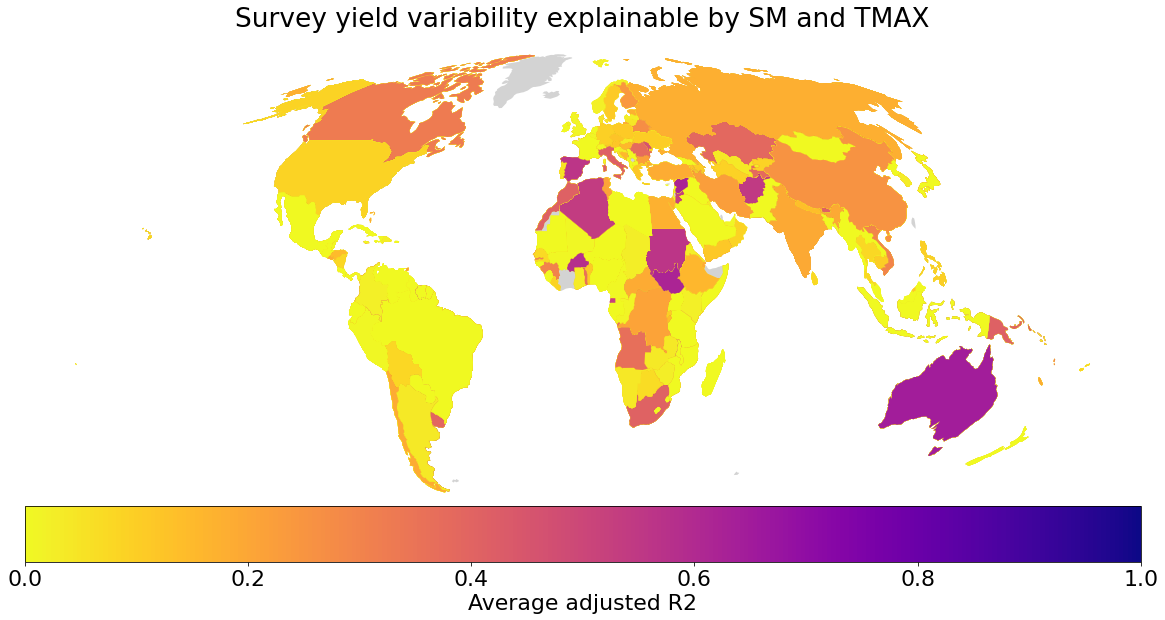

In [ ]:

plot_map(regs[regs['model']=="Survey"], column="adj_r2", 
         title="Survey yield variability explainable by SM and TMAX", 
         cbar_label="Average adjusted R2", cmap="plasma_r", vmin=0, vmax=1,
         filename="survey_weather")

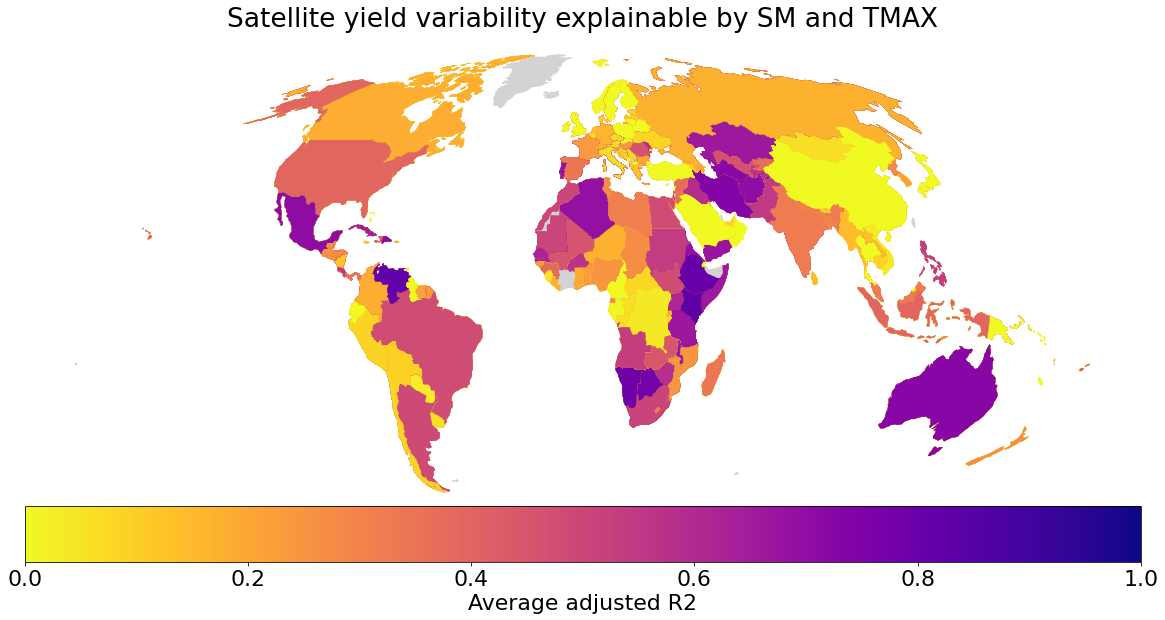

In [ ]:

plot_map(regs[regs['model']=="Satellite"], column="adj_r2", 
         title="Satellite yield variability explainable by SM and TMAX", 
         cbar_label="Average adjusted R2", cmap="plasma_r", vmin=0, vmax=1,
         filename="satellite_weather")